In [1]:
from graph import build_graph, get_feedback_notes
from state import BlogState, RevisionNotes
from agents import get_llm, research_agent, writer_agent, editor_agent
from langgraph.types import Command

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
graph = build_graph()

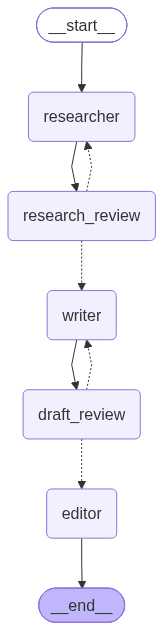

In [4]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## Testing agents seperately

In [17]:
research = research_agent(get_llm(), "Why jantar mantar is the prime location for every protest?", "general")

Searching Wikipedia for: Jantar Mantar protest location
Searching DuckDuckGo for: Jantar Mantar protest 2026 statistics
Searching Wikipedia for: Jantar Mantar protests history


In [18]:
print(research)


# Executive Summary  
Jantar Mantar in New Delhi has emerged as a symbolic and strategic hub for contemporary protests, most notably the 2026 student‑led demonstrations against examination irregularities and the resignation of Education Minister Dharmendra Pradhan. Its historical stature as a public observatory, its central location opposite Parliament, and its long‑standing tradition of civic assembly make it an ideal staging ground for mass mobilization. Recent events have highlighted its role in amplifying dissent, shaping policy outcomes, and exposing tensions between civil society and state authority.

---

# Background  
- **Historical Significance**: Built in 1724 by Sawai Jai Singh, Jantar Mantar is one of five astronomical observatories in India. It has long been a public space for scientific education and civic engagement.  
- **Geographical Advantage**: Situated in the heart of New Delhi, directly opposite the Parliament House, it offers symbolic proximity to national decisi

In [19]:
draft = writer_agent(get_llm(), research, "Write a blog post about the student protest at jantar mantar", "general")

In [20]:
print(draft)

# Jantar Mantar: The New Epicenter of Student Protest in Delhi

When you think of protests in India, the image that often pops up is a sea of people marching in front of Parliament. But the real heartbeat of dissent has shifted to a place that predates the nation itself – the ancient observatory of Jantar Mantar in New Delhi. In 2026, a wave of student‑led demonstrations erupted there, demanding an overhaul of the national exam system and the resignation of Education Minister Dharmendra Pradhan. The protests not only shook the political landscape but also highlighted how a historic public space can become a modern stage for civic engagement.

---

## 1. Why Jantar Mantar? A Quick History Lesson

| Fact | Detail |
|------|--------|
| **Built** | 1724 by Sawai Jai Singh |
| **Purpose** | Public astronomical observatory |
| **Location** | Opposite Parliament House, heart of New Delhi |
| **Legacy** | Long‑standing civic assembly hub |

Jantar Mantar was originally a place where citizens c

In [21]:
blog = editor_agent(get_llm(), "Write a blog post about the student protest at jantar mantar", "general", draft)

In [22]:
print(blog)

# Jantar Mantar: Delhi’s New Protest Hub

When most people think of protests in India, they picture crowds outside Parliament. But in 2026 a new epicenter of dissent emerged at the historic Jantar Mantar observatory in New Delhi. Student demonstrators gathered there to demand a complete overhaul of the national exam system and the resignation of Education Minister Dharmendra Pradhan. The protests not only shook the political landscape but also showed how a public space steeped in history can become a modern stage for civic engagement.

---

## 1. Why Jantar Mantar? A Quick History Lesson

| Fact | Detail |
|------|--------|
| Built | 1724 by Sawai Jai Singh |
| Purpose | Public astronomical observatory |
| Location | Opposite Parliament House, heart of New Delhi |
| Legacy | Long‑standing civic assembly hub |

Jantar Mantar was originally a place where citizens could learn about the stars. Over the centuries it evolved into a public square for discussion and protest. Its open plaza, su

## Testing Graph

In [5]:
config = {"configurable": {"thread_id": "1"}}

In [6]:
state = graph.invoke(
    {
        "topic": "What is MCP (Model Context Protocol)? A developer's guide for 2026",
        "audience": "AI developers and enthusiasts",
    },
    config= config
)

Searching DuckDuckGo for: MCP Model Context Protocol 2026
Searching Wikipedia for: Model Context Protocol
Searching DuckDuckGo for: MCP Model Context Protocol 2026 update
Searching arXiv for: Model Context Protocol MCP 2024 2025
research_review


In [7]:
snap = graph.get_state(config=config)

In [8]:
interrupt_payload = snap.interrupts[0].value

In [9]:
print("Stage:", interrupt_payload.get("stage"))
print("\n ------------Research Content for YOUR review------------ \n")
print(interrupt_payload.get("research_content"))

Stage: research_review

 ------------Research Content for YOUR review------------ 

# Executive Summary  
The Model Context Protocol (MCP) is an open‑standard framework that emerged in late 2024, designed to unify how large language models (LLMs) ingest, share, and act on contextual data from external systems. By defining a declarative schema for files, APIs, databases, and interactive UI components, MCP enables developers to build modular, interoperable AI applications without custom integration layers. Since its release, MCP has been adopted by major AI vendors, integrated into popular developer toolkits, and benchmarked in the 2025 MCP‑Universe study. This report synthesizes the protocol’s technical foundation, recent industry uptake, academic validation, and practical guidance for developers in 2026.

# Background  
MCP was introduced by Anthropic in November 2024 as a response to fragmented tool‑integration practices in the LLM ecosystem. The protocol specifies a JSON‑based “conte

In [10]:
research_feedback = input(f"{interrupt_payload.get('instructions')}")
state = graph.invoke(
    Command(resume={"feedback":research_feedback}),
    config=config
)

research_review
draft_review


In [11]:
print(state.get("draft"))

# What is MCP (Model Context Protocol)? A Developer’s Guide for 2026  

Large‑language models (LLMs) are no longer just “chat” engines. They’re becoming orchestration hubs that pull data from files, APIs, databases, and even user interfaces. The **Model Context Protocol (MCP)** is the open‑standard that lets developers describe *all* those data sources in a single, machine‑readable contract. In this post we’ll unpack what MCP is, why it matters in 2026, and how you can start using it today.

---

## 1. The MCP Primer  

### 1.1  What Is MCP?  
MCP is a JSON‑based schema that bundles together:

| Item | What it describes | Why it matters |
|------|-------------------|----------------|
| **Files** | Paths, formats, and metadata | Enables LLMs to read CSVs, PDFs, or images without custom parsers |
| **APIs** | Endpoints, request/response types, auth | Lets the model call external services in a typed way |
| **Databases** | Connection strings, table schemas | Allows the model to query stru

In [13]:
snap = graph.get_state(config=config)
interrupt_payload = snap.interrupts[0].value
print("Stage:", interrupt_payload.get("stage"))
print("\n ------------Draft for YOUR review------------ \n")
print(interrupt_payload.get("draft"))

Stage: draft_review

 ------------Draft for YOUR review------------ 

# What is MCP (Model Context Protocol)? A Developer’s Guide for 2026  

Large‑language models (LLMs) are no longer just “chat” engines. They’re becoming orchestration hubs that pull data from files, APIs, databases, and even user interfaces. The **Model Context Protocol (MCP)** is the open‑standard that lets developers describe *all* those data sources in a single, machine‑readable contract. In this post we’ll unpack what MCP is, why it matters in 2026, and how you can start using it today.

---

## 1. The MCP Primer  

### 1.1  What Is MCP?  
MCP is a JSON‑based schema that bundles together:

| Item | What it describes | Why it matters |
|------|-------------------|----------------|
| **Files** | Paths, formats, and metadata | Enables LLMs to read CSVs, PDFs, or images without custom parsers |
| **APIs** | Endpoints, request/response types, auth | Lets the model call external services in a typed way |
| **Databases*

In [14]:
draft_feedback = input(f"{interrupt_payload.get('instructions')}")
state = graph.invoke(
    Command(resume={"feedback": draft_feedback}),
    config=config
)

draft_review
draft_review


In [15]:
print(state.get("draft"))

# What Is MCP (Model Context Protocol)? A Developer’s Guide for 2026  

The AI landscape of 2026 is a mosaic of LLMs, multimodal models, and increasingly sophisticated tool‑chains. Yet one persistent pain point remains: **how do we let a language model talk to the world in a predictable, auditable, and reusable way?**  
Enter the **Model Context Protocol (MCP)**—an open‑standard framework that turns the messy “plug‑and‑play” of external APIs, databases, and UI widgets into a single, declarative contract.  

In this post we’ll unpack MCP’s core concepts, show why it’s already a de‑facto standard, and walk through concrete use cases—from community‑driven research to citizen science. By the end you’ll know how to start using MCP today, what pitfalls to avoid, and where the protocol is headed next.

---

## 1. MCP 101 – The Building Blocks

| Concept | What It Is | Why It Matters |
|---------|------------|----------------|
| **Context Bundle** | A JSON document that lists every data source

In [16]:
snap = graph.get_state(config=config)
interrupt_payload = snap.interrupts[0].value
print("Stage:", interrupt_payload.get("stage"))
print("\n ------------Draft for YOUR review------------ \n")
print(interrupt_payload.get("draft"))

Stage: draft_review

 ------------Draft for YOUR review------------ 

# What Is MCP (Model Context Protocol)? A Developer’s Guide for 2026  

The AI landscape of 2026 is a mosaic of LLMs, multimodal models, and increasingly sophisticated tool‑chains. Yet one persistent pain point remains: **how do we let a language model talk to the world in a predictable, auditable, and reusable way?**  
Enter the **Model Context Protocol (MCP)**—an open‑standard framework that turns the messy “plug‑and‑play” of external APIs, databases, and UI widgets into a single, declarative contract.  

In this post we’ll unpack MCP’s core concepts, show why it’s already a de‑facto standard, and walk through concrete use cases—from community‑driven research to citizen science. By the end you’ll know how to start using MCP today, what pitfalls to avoid, and where the protocol is headed next.

---

## 1. MCP 101 – The Building Blocks

| Concept | What It Is | Why It Matters |
|---------|------------|---------------

In [17]:
draft_feedback = input(f"{interrupt_payload.get('instructions')}")
state = graph.invoke(
    Command(resume={"feedback": draft_feedback}),
    config=config
)

draft_review


In [20]:
print(state.get("final_blog_post"))

# What Is MCP (Model Context Protocol)? A 2026 Guide for AI Developers  

The AI landscape in 2026 is a mosaic of LLMs, multimodal models, and increasingly sophisticated tool‑chains. Yet one persistent pain point remains: **how do we let a language model talk to the world in a predictable, auditable, and reusable way?**  

Enter the **Model Context Protocol (MCP)**—an open‑standard framework that turns the messy “plug‑and‑play” of external APIs, databases, and UI widgets into a single, declarative contract.  

In this post we’ll unpack MCP’s core concepts, show why it’s already a de‑facto standard, and walk through concrete use cases—from community‑driven research to citizen science. By the end you’ll know how to start using MCP today, what pitfalls to avoid, and where the protocol is headed next.

---

## 1. MCP 101 – The Building Blocks  

| Concept | What It Is | Why It Matters |
|---------|------------|----------------|
| **Context Bundle** | A JSON document that lists every data s